In [6]:
#import packages
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nilearn import datasets, image
from nilearn.connectome import ConnectivityMeasure
from nilearn.maskers import NiftiLabelsMasker
from nilearn.glm.first_level import FirstLevelModel

In [7]:
BASE_DIR     = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Dataset")
SUBJECT      = 100206
TASK         = "EMOTION"     # 또는 "EMOTION"
PHASE        = "LR"          # "LR" 또는 "RL"

In [8]:
aal = datasets.fetch_atlas_aal()
aal_img    = aal.maps    # AAL atlas NIfTI 경로
aal_labels = aal.labels  # ROI 이름 리스트

[get_dataset_dir] Dataset found in C:\Users\JINHWA\nilearn_data\aal_SPM12


In [10]:
masker    = NiftiLabelsMasker(
    labels_img       = aal_img,
    standardize      = "zscore_sample",
    detrend          = True,
    low_pass         = None,
    high_pass        = None,
    t_r              = 0.72,
    resampling_target = "data"
)

In [11]:
def make_paths(subject, task, phase="LR"):
    img_path = BASE_DIR / f"{subject:06d}/MNINonLinear/Results/tfMRI_{task}_{phase}/tfMRI_{task}_{phase}.nii.gz"
    ev_dir   = img_path.parent / "EVs"
    return img_path, ev_dir

In [12]:
def get_residual(img_path: Path, ev_dir: Path):
    """
    EVs 폴더 내의 *.txt 파일들을 건너뛰기 로직과 함께 읽어서
    onset/duration 정보를 모은 뒤, FirstLevelModel로 GLM을 수행한 후
    residual 4D 이미지를 반환합니다.
    """
    events = []

    for ev_file in sorted(ev_dir.glob("*.txt")):
        # 1) 순수히 숫자가 아닌 파일은 건너뛰기
        try:
            data = np.loadtxt(ev_file)
        except Exception:
            continue

        # 2) 빈 파일 혹은 숫자가 0개라면 건너뜀
        if data.size == 0:
            continue

        # 3) 1차원 배열(단일 행)인 경우, 열 개수 확인
        if data.ndim == 1:
            if data.shape[0] < 2:
                # onset/duration 정보를 담기 어렵다면 건너뜀
                continue
            data = data.reshape(1, -1)

        # 4) 2차원 배열(여러 행)인 경우, 열 개수가 2 또는 3인지 확인
        if data.ndim == 2:
            n_cols = data.shape[1]
            if n_cols not in (2, 3):
                continue
        else:
            # ndim이 0 또는 3 이상이면 건너뜀
            continue

        # 5) 최종적으로 data가 (N_events, 2) 혹은 (N_events, 3) 모양으로 보장됨
        if data.shape[1] == 3:
            onset_arr, duration_arr, _ = data.T
        else:  # data.shape[1] == 2
            onset_arr, duration_arr = data.T

        for o, d in zip(onset_arr, duration_arr):
            events.append({
                "onset":      float(o),
                "duration":   float(d),
                "trial_type": ev_file.stem
            })

    # 만약 events 리스트가 비어 있으면 None 반환
    if not events:
        return None

    # 이벤트가 모였다면 DataFrame으로 정리하고 GLM → residual 반환
    events_df = pd.DataFrame(events, columns=["onset", "duration", "trial_type"])
    fmri_img  = image.load_img(str(img_path))
    model     = FirstLevelModel(
        t_r              = 0.72,
        drift_model      = "polynomial",
        standardize      = False,
        minimize_memory  = False
    ).fit(fmri_img, events=events_df)

    return model.residuals[0]  # list이므로 첫 번째 residual 4D 이미지 반환

In [13]:
def sliding_window_dist(ts: np.ndarray, win: int, step: int) -> np.ndarray:
    """
    ts: (T, P) shaped array, T = time points, P = number of ROIs
    win: window length in TRs
    step: sliding step in TRs

    반환값: (n_windows, P, P) shaped array of 1 - |correlation| distance matrices
    """
    connectivity = ConnectivityMeasure(kind="correlation")
    T, P        = ts.shape
    n_windows   = (T - win) // step + 1
    out         = np.zeros((n_windows, P, P), dtype=np.float32)

    for idx, start in enumerate(range(0, T - win + 1, step)):
        segment      = ts[start : start + win]
        corr_matrix  = connectivity.fit_transform([segment])[0]
        dist_matrix  = 1.0 - np.abs(corr_matrix)
        out[idx]     = dist_matrix

    return out

In [14]:
OUT_DIR = Path("C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts")
OUT_DIR.mkdir(exist_ok=True)

In [15]:
img_path, ev_dir = make_paths(SUBJECT, TASK, PHASE)
print(f"Loading {TASK} {PHASE} run from: {img_path}")

Loading EMOTION LR run from: C:\Users\JINHWA\Projects\BrainNetworkTDA\Dataset\100206\MNINonLinear\Results\tfMRI_EMOTION_LR\tfMRI_EMOTION_LR.nii.gz


In [16]:
resid_img = get_residual(img_path, ev_dir)
if resid_img is None:
    raise RuntimeError(f"No usable EV files found for {TASK} {PHASE} run.")

c:\Users\JINHWA\miniconda3\envs\tda\Lib\site-packages\nilearn\glm\first_level\first_level.py:585: UserWarning: Mean values of 0 observed. The data have probably been centered.Scaling might not work as expected
  Y, _ = mean_scaling(Y, self.signal_scaling)


In [17]:
WINDOW_SIZE  = 24            # TR 단위
STEP_SIZE    = 3             # TR 단위

In [18]:
ts_resid = masker.fit_transform(resid_img)   # shape = (T, n_rois)
T, n_rois = ts_resid.shape
print(f"Extracted time-series shape: {ts_resid.shape}")

Extracted time-series shape: (176, 116)


In [ ]:
TR = 0.72
total_duration = T * TR
print(f"fMRI 총 길이: {T} TR ≈ {total_duration:.2f}초")


fMRI 총 길이: 176 TR ≈ 126.72초


In [19]:
# ───────────────
# Raw block data (from EVs of Emotion LR)
# Format: (label, onset, duration)
# ───────────────
raw_blocks = [
    ("fear",      8.032, 18.0),
    ("neutral",  30.996, 18.0),
    ("fear",     54.000, 18.0),
    ("neutral",  76.952, 18.0),
    ("fear",     99.971, 18.0),
    ("neutral", 122.966, 18.0),
]

# ───────────────
# 1. Compute block TR range
# ───────────────
events = []
for label, onset, duration in raw_blocks:

    start_tr = int(np.floor(onset / TR))
    end_tr   = int(np.ceil((onset + duration) / TR)) - 1
    events.append({
        "trial_type": label,
        "onset_sec":  onset,
        "duration_s": duration,
        "start_tr":   start_tr,
        "end_tr":     end_tr
    })

ev_df = pd.DataFrame(events)
print("\n=== BLOCKS  ===")
print(ev_df[["trial_type", "start_tr", "end_tr"]].to_string(index=False))

# ───────────────
# 2. Sliding Window Labeling (based on ts_resid of length 253)
# ───────────────

n_windows = (T - WINDOW_SIZE) // STEP_SIZE + 1

window_labels = []
for t in range(n_windows):
    center_tr = t * STEP_SIZE + (WINDOW_SIZE // 2)
    hit = ev_df[(ev_df["start_tr"] <= center_tr) & (ev_df["end_tr"] >= center_tr)]
    window_labels.append(hit.iloc[0]["trial_type"] if not hit.empty else "no_event")

win_df = pd.DataFrame({
    "window_index": np.arange(n_windows),
    "center_tr":    np.arange(n_windows) * STEP_SIZE + (WINDOW_SIZE // 2),
    "block_label":  window_labels
})

print("\n=== WINDOW LABELS ===")
print(win_df.to_string(index=False))


=== BLOCKS  ===
trial_type  start_tr  end_tr
      fear        11      36
   neutral        43      68
      fear        75      99
   neutral       106     131
      fear       138     163
   neutral       170     195

=== WINDOW LABELS ===
 window_index  center_tr block_label
            0         12        fear
            1         15        fear
            2         18        fear
            3         21        fear
            4         24        fear
            5         27        fear
            6         30        fear
            7         33        fear
            8         36        fear
            9         39    no_event
           10         42    no_event
           11         45     neutral
           12         48     neutral
           13         51     neutral
           14         54     neutral
           15         57     neutral
           16         60     neutral
           17         63     neutral
           18         66     neutral
           19    

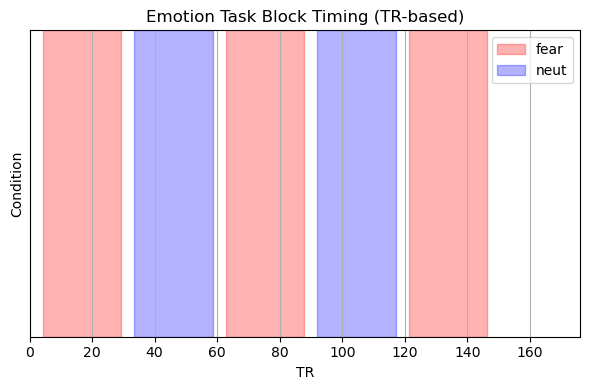

In [20]:
# 원래 초 단위로 쓰던 onset들을 TR 단위로 변환
blocks = [
    ("fear", 3.074, "red"),
    ("neut", 24.145, "blue"),
    ("fear", 45.217, "red"),
    ("neut", 66.288, "blue"),
    ("fear", 87.359, "red"),
]

plt.figure(figsize=(6, 4))

for label, onset_sec, color in blocks:
    onset_tr = onset_sec / TR
    duration_tr = 18 / TR  # block duration = 18s → 25 TR
    label_text = label if label not in plt.gca().get_legend_handles_labels()[1] else ""
    plt.axvspan(onset_tr, onset_tr + duration_tr, color=color, alpha=0.3, label=label_text)

plt.xlabel("TR")
plt.ylabel("Condition")
plt.title("Emotion Task Block Timing (TR-based)")
plt.xlim(0, 176)
plt.yticks([])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
dist_tensor = sliding_window_dist(ts_resid, WINDOW_SIZE, STEP_SIZE)
print(f"Distance tensor shape: {dist_tensor.shape}")

Distance tensor shape: (51, 116, 116)


In [22]:
out_path = OUT_DIR / f"{SUBJECT}_{TASK}_{PHASE}_AAL_resid_abs_dist.npy"
np.save(out_path, dist_tensor)
print(f"Saved → {out_path}")

Saved → C:\Users\JINHWA\Projects\BrainNetworkTDA\Usedata\tfMRI_ts\100206_EMOTION_LR_AAL_resid_abs_dist.npy


In [23]:
OUT_DIR = Path(f"C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts/{SUBJECT:06d}_emotion_dist")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [24]:
for i, mat in enumerate(dist_tensor):
    # 파일명 예시: rs100206_dist_matrix_000.txt, rs100206_dist_matrix_001.txt, ...
    file_path = OUT_DIR / f"emotion{SUBJECT}_dist_matrix_{i:03d}.txt"
    np.savetxt(file_path, mat, fmt='%.6f')
    # (원하는 경우, delimiter='\t' 등을 추가할 수 있습니다)
    # 예: np.savetxt(file_path, mat, fmt='%.6f', delimiter='\t')
    #print(f"Saved → {file_path}")

In [25]:
# Load the .txt file
txtfile = f'C:/Users/JINHWA/Projects/BrainNetworkTDA/Usedata/tfMRI_ts/100206_emotion_dist/emotion{SUBJECT:06d}_dist_matrix_000.txt'
data = np.loadtxt(txtfile)

# Sanity checks
print("=== TXT File Sanity Check ===")
print(f"Shape                : {data.shape}")  # Expecting (116, 116)
print(f"Number of entries    : {data.size}")
print(f"Expected entries     : 116 * 116 = {116 * 116}")
print(f"Min value            : {np.min(data):.4f}")
print(f"Max value            : {np.max(data):.4f}")
print(f"Any NaNs             : {np.isnan(data).any()}") # False: All values are real numbers
print(f"Any Infs             : {np.isinf(data).any()}") # False: All values are finite and valid

=== TXT File Sanity Check ===
Shape                : (116, 116)
Number of entries    : 13456
Expected entries     : 116 * 116 = 13456
Min value            : 0.0000
Max value            : 1.0000
Any NaNs             : False
Any Infs             : False


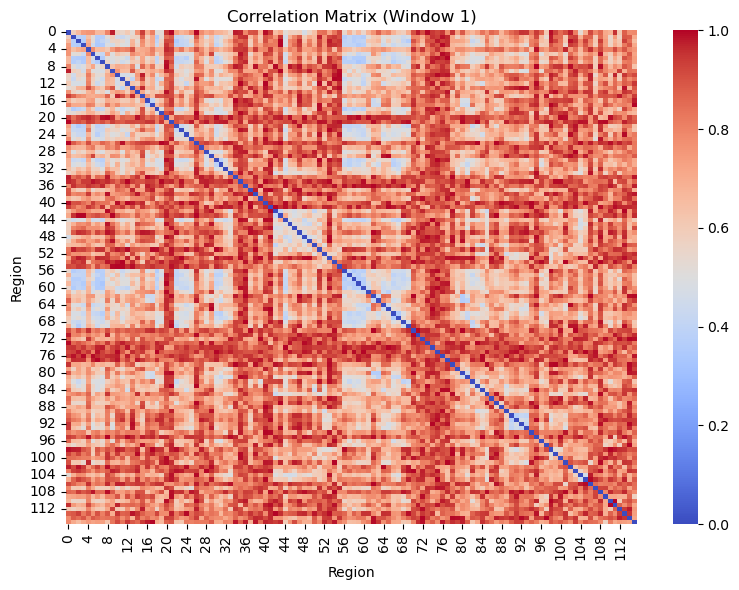

In [26]:
# === Plot sample heatmap ===
plt.figure(figsize=(8, 6))
sns.heatmap(dist_tensor[0], cmap='coolwarm', vmin=0, vmax=1)
plt.title("Correlation Matrix (Window 1)")
plt.xlabel("Region")
plt.ylabel("Region")
plt.tight_layout()
plt.show()